In [1]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx
import pandas as pd
import nibabel as nib

import matplotlib.pyplot as plt

from dmri.utils.viz import set_style

plt.style.use("../../dmri/utils/pyloric.mplstyle")

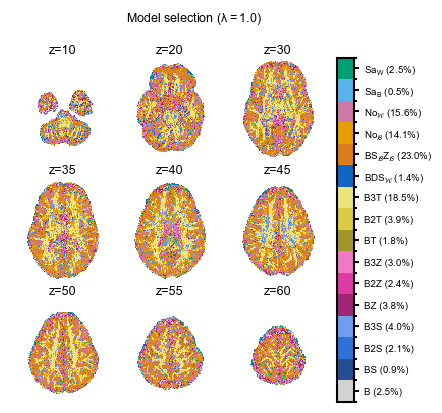

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [2]:
from model_segmentation_plot import plot_model_segmentation, plot_model_freqs, get_model_freq, plot_model_segmentation_zgrid, plot_model_freqs, _shorthand, plot_bump, build_rank_df
plot_model_segmentation_zgrid(
    "../all_conv_figs/data0_p10/model_probs_preselected_conv_prior_1.0.nii.gz",
    "../all_conv_figs/data0_p10/preselected_models_summary_conv_1.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_sel_all/model_segmentation_conv_10.svg",
    fig_title="Model selection ($\lambda=1.0$)",
)


/tmp/ipykernel_3718107/2536334851.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['0', '', '', '','1.'])


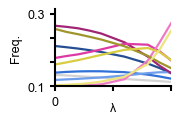

In [17]:
fig, ax = plot_model_freqs(fig_size=(1.5,1.), group_similar=True, output_png=None, output_svg=None, show=False)
ax.set_ylim(0, 0.32)
ax.set_yticks([0.0,0.1, 0.2,0.3])
ax.set_yticklabels(['0.1', '', '', '0.3'])
ax.set_xticklabels(['0', '', '', '','1.'])
ax.set_ylabel("Freq.")
fig.savefig("model_frequencies_in_brain_big.svg")

/tmp/ipykernel_3718107/413675083.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['0', '', '', '','1.'])


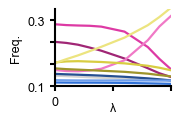

In [18]:
fig, ax = plot_model_freqs(fig_size=(1.5,1.), group_similar=True, output_png=None, output_svg=None, show=False, data=1)
ax.set_ylim(0, 0.35)
ax.set_yticks([0.0,0.1, 0.2,0.3])
ax.set_yticklabels(['0.1', '', '', '0.3'])
ax.set_xticklabels(['0', '', '', '','1.'])
ax.set_ylabel("Freq.")
fig.savefig("model_frequencies_in_brain_big_2.svg")

In [5]:
for i in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9, 1.0]:
    print(i)
    print(list(map(_shorthand, get_model_freq(i, data=0, mode="top10", return_models=True)[0])))


0.0
['BZ', 'BT', 'BZT', 'BSZ', 'BS', 'BST', 'B', 'B2Z', '2Z', 'B2S']
0.1
['BZ', 'BT', 'BZT', 'BSZ', 'BS', 'BST', 'B', 'B2Z', '2Z', 'B2S']
0.2
['BZ', 'BZT', 'BT', 'BSZ', 'BS', 'BST', 'B', 'B2Z', '2Z', 'B2S']
0.3
['BZ', 'BZT', 'BT', 'BSZ', 'BS', 'BST', '2Z', 'B2Z', 'B', 'B2S']
0.4
['BZ', 'BZT', 'BT', 'BSZ', 'BS', 'BST', '2Z', 'B2Z', 'B', 'BSZT']
0.5
['BZ', 'BZT', 'BSZ', 'BT', 'BS', 'BST', 'B2Z', '2Z', 'B', 'BSZT']
0.6
['BZ', 'BZT', 'BSZ', 'BT', 'B2Z', '2Z', 'BS', 'BST', 'B', 'BSZT']
0.8
['BZT', 'BZ', 'B2Z', 'BSZ', '2Z', 'BT', 'BZ2T', 'S2Z', 'BS', 'BST']
0.9
['BZT', 'BZ', 'B2Z', 'BSZ', '2Z', 'BZ2T', 'B3Z', 'BT', 'B2ZT', 'S2Z']
1.0
['BZT', 'B2Z', 'B3Z', 'BZ', 'BZ2T', '2Z', 'BSZ', 'B2ZT', 'BZ3T', 'B3ZT']


In [6]:
df = build_rank_df(data=0, mode="top10", shorthand=True)

In [7]:
df2 = build_rank_df(data=1, mode="top10", shorthand=True)

In [8]:
df3 = build_rank_df(data=0, mode="top10", shorthand=True, data_path="../all_conv_figs/", summary_prefix="conv_")

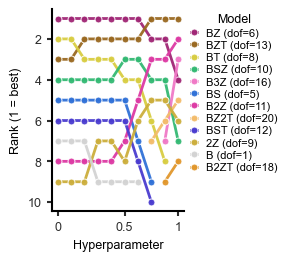

In [21]:
fig,ax = plot_bump(df, group_similar=True, figsize=(2.8,2.5))
fig.savefig("model_ranks_bump_plot.svg", transparent=True)


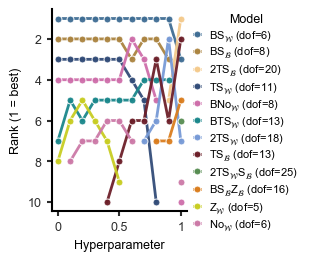

In [22]:
fig,ax = plot_bump(df3, group_similar=True, figsize=(3.,2.5))
fig.savefig("model_ranks_bump_plot_conv.pdf", transparent=True)

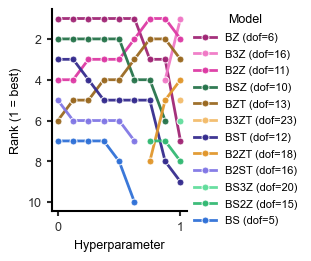

In [9]:
fig, ax = plot_bump(df2, group_similar=True, figsize=(3.,2.5))
fig.savefig("model_ranks_bump_plot_2.svg")

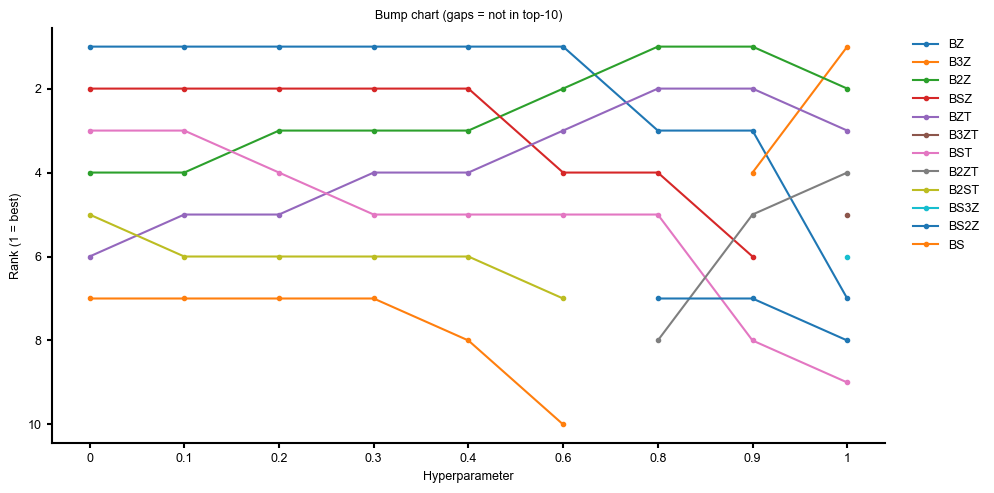

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HYPERS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,0.8, 0.9, 1.0]

def _extract_models(res):
    # handles either `models` or `(models, ...)` style returns
    if isinstance(res, (tuple, list)) and len(res) and isinstance(res[0], (list, tuple, np.ndarray, pd.Series)):
        return list(res[0])
    return list(res)

def build_rank_df(hypers=HYPERS, data=1, mode="top10", shorthand=True):
    rows = []
    for h in hypers:
        try:
            res = get_model_freq(h, data=data, mode=mode, return_models=True)
            models = _extract_models(res)
            if shorthand:
                models = list(map(_shorthand, models))

            L = len(models)
            for r, m in enumerate(models, start=1):
                rows.append({"hyper": float(h), "model": m, "rank": r, "list_length": L})
        except Exception as e:
            pass
    return pd.DataFrame(rows)

df = build_rank_df()

def plot_bump(df, models=None, topM=12, figsize=(10, 5)):
    hypers = sorted(df["hyper"].unique())

    if models is None:
        # pick models with best mean rank among those appearing often
        tmp = (df.groupby("model")
                 .agg(n=("hyper","nunique"), mean_rank=("rank","mean"))
                 .sort_values(["mean_rank","n"], ascending=[True, False]))
        models = tmp.head(topM).index.tolist()

    pivot = df[df["model"].isin(models)].pivot_table(
        index="model", columns="hyper", values="rank", aggfunc="min"
    ).reindex(columns=hypers)

    x = np.arange(len(hypers))
    plt.figure(figsize=figsize)
    for m in models:
        y = pivot.loc[m].to_numpy()
        plt.plot(x, y, marker="o", label=m)

    plt.gca().invert_yaxis()
    plt.xticks(x, [f"{h:g}" for h in hypers])
    plt.xlabel("Hyperparameter")
    plt.ylabel("Rank (1 = best)")
    plt.title(f"Bump chart (gaps = not in top-10)")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

plot_bump(df, topM=12)


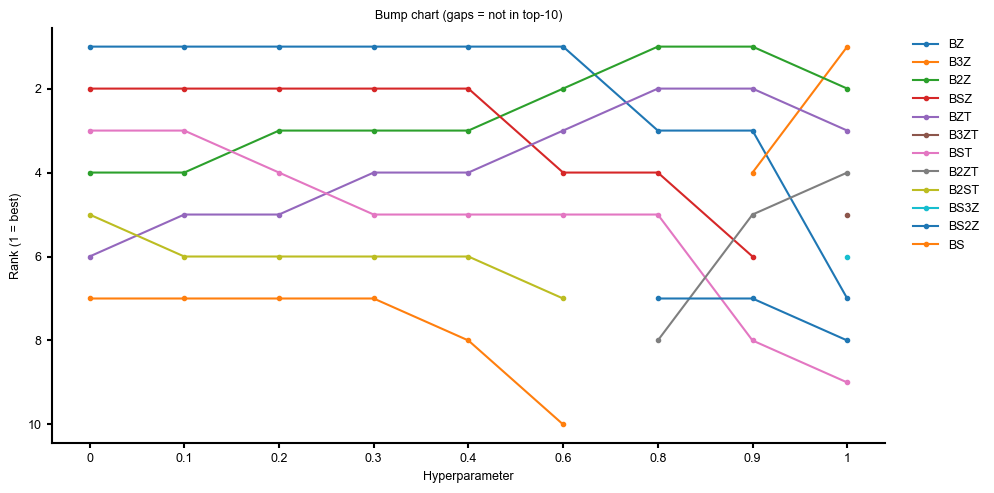

In [27]:
get_model_freq(1.0, data=0, mode="top10", return_models=True)

(['Ball>Zeppelin>Dti',
  'Ball>Zeppelin>Zeppelin',
  'Ball>Zeppelin>Zeppelin>Zeppelin',
  'Ball>Zeppelin',
  'Ball>Zeppelin>Dti>Dti',
  'Zeppelin>Zeppelin',
  'Ball>Stick>Zeppelin',
  'Ball>Zeppelin>Zeppelin>Dti',
  'Ball>Zeppelin>Dti>Dti>Dti',
  'Ball>Zeppelin>Zeppelin>Zeppelin>Dti'],
 array([0.26622382, 0.14209534, 0.13392789, 0.0886621 , 0.08085475,
        0.07014358, 0.06366172, 0.05956267, 0.04932653, 0.04554161]))

/tmp/ipykernel_2336417/967718083.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['0', '', '', '','1.'])


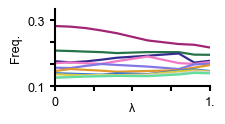

In [6]:
fig, ax = plot_model_freqs(fig_size=(2.,1.), group_similar=True, output_png=None, output_svg=None, show=False, data=1, mode="top10")
ax.set_ylim(0, 0.35)
ax.set_yticks([0.0,0.1, 0.2,0.3])
ax.set_yticklabels(['0.1', '', '', '0.3'])
ax.set_xticklabels(['0', '', '', '','1.'])
ax.set_ylabel("Freq.")
fig.savefig("model_frequencies_in_brain_big_2.svg")

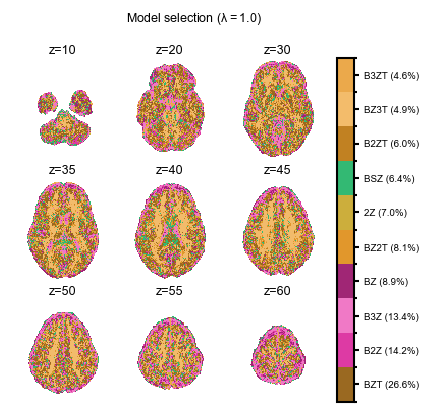

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [16]:
plot_model_segmentation_zgrid(
    "outputs/data0_p10/model_probs_top10_prior_1.0.nii.gz",
    "outputs/data0_p10/top10_models_summary_1.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_sel_all/model_segmentation_conv_10.svg",
    fig_title="Model selection ($\lambda=1.0$)",
)


/tmp/ipykernel_2336417/2374980941.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['0', '', '', '','1.'])


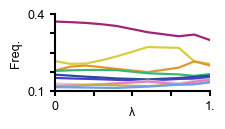

In [10]:
fig, ax = plot_model_freqs(fig_size=(2.,1.), group_similar=True, output_png=None, output_svg=None, show=False, data=0, mode="top10")
ax.set_ylim(0, 0.4)
ax.set_yticks([0.0,0.1, 0.2,0.3, 0.4])
ax.set_yticklabels(['0.1', '', '', '', '0.4'])
ax.set_xticklabels(['0', '', '', '','1.'])
ax.set_ylabel("Freq.")
fig.savefig("model_frequencies_in_brain_big_2.svg")

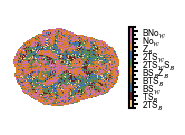

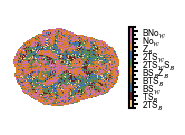

In [29]:
plot_model_segmentation(
    "../all_conv_figs/data0_p10/model_probs_top10_conv_prior_1.0.nii.gz",
    "../all_conv_figs/data0_p10/top10_models_summary_conv_1.0.csv",
    group_similar=True,
    show_percent=False,
    fig_size=(2.,1.5),
    axial_only=True,
    colorbar_location='right',
    axial_rotate_k=3,
    show_titles=False,
    fontsize=6,
    colorbar_length=0.7,
    output_svg="fig_model_sel_all/small_top10.pdf",
    #fig_title="Model selection ($\lambda=1.0$)",
)

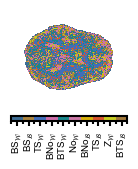

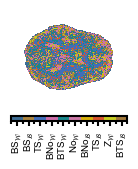

In [ ]:
plot_model_segmentation(
    "../all_conv_figs/data0_p05/model_probs_top10_conv_prior_0.5.nii.gz",
    "../all_conv_figs/data0_p05/top10_models_summary_conv_0.5.csv",
    group_similar=True,
    show_percent=False,
    fig_size=(1.5,1.5),
    axial_only=True,
    colorbar_location='bottom',
    axial_rotate_k=3,
    show_titles=False,
    output_svg="fig_model_sel_all/small_top10_0.5.svg",
    #fig_title="Model selection ($\lambda=1.0$)",
)

In [30]:
plot_model_segmentation(
    "outputs/data0_p07/model_probs_top10_prior_0.7.nii.gz",
    "outputs/data0_p07/top10_models_summary_0.7.csv",
    group_similar=True,
    show_percent=False,
    fig_size=(1.5,1.5),
    axial_only=True,
    colorbar_location='bottom',
    axial_rotate_k=3,
    show_titles=False,
    output_svg="fig_model_all/small_top10_0.7.svg",
    #fig_title="Model selection ($\lambda=1.0$)",
)

FileNotFoundError: No such file or no access: 'outputs/data0_p07/model_probs_top10_prior_0.7.nii.gz'

In [ ]:
plot_model_segmentation(
    "../all_conv_figs/data0_p10/model_probs_preselected_conv_prior_1.0.nii.gz",
    "../all_conv_figs/data0_p10/preselected_models_summary_conv_1.0.csv",
    group_similar=True,
    show_percent=False,
    fig_size=(1.5,1.5),
    axial_only=True,
    output_svg="fig_model_sel_all/small.svg",
    #fig_title="Model selection ($\lambda=1.0$)",
)

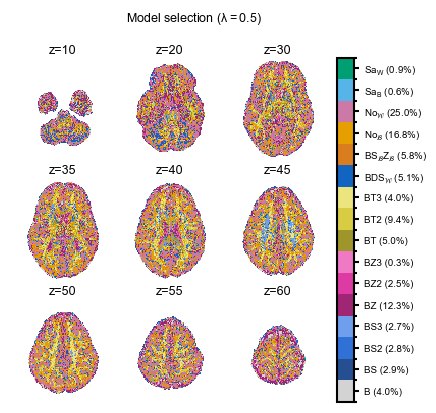

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [9]:
from model_segmentation_plot import plot_model_segmentation, plot_model_freqs, get_model_freq, plot_model_segmentation_zgrid
plot_model_segmentation_zgrid(
    "../all_conv_figs/data0_p05/model_probs_preselected_conv_prior_0.5.nii.gz",
    "../all_conv_figs/data0_p05/preselected_models_summary_conv_0.5.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_sel_all/model_segmentation_conv_05.svg",
    fig_title="Model selection ($\lambda=0.5$)"
)


In [ ]:
plot_model_segmentation_zgrid(
    "../all_conv_figs/data0_p00/model_probs_preselected_conv_prior_0.0.nii.gz",
    "../all_conv_figs/data0_p00/preselected_models_summary_conv_0.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_sel_all/model_segmentation_conv_00.svg",
    fig_title="Model selection ($\lambda=0.0$)"

)


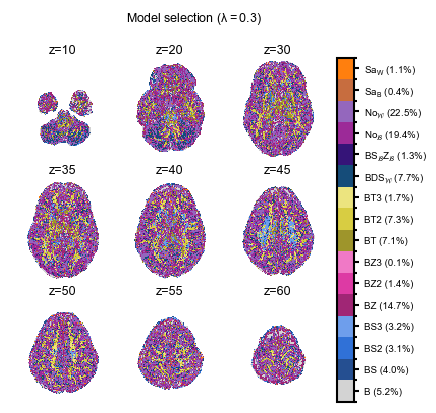

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [6]:
from model_segmentation_plot import plot_model_segmentation, plot_model_freqs, get_model_freq, plot_model_segmentation_zgrid
plot_model_segmentation_zgrid(
    "../all_conv_figs/data0_p03/model_probs_preselected_conv_prior_0.3.nii.gz",
    "../all_conv_figs/data0_p03/preselected_models_summary_conv_0.3.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_sel_all/model_segmentation_conv_03.svg",
    fig_title="Model selection ($\lambda=0.3$)"
)


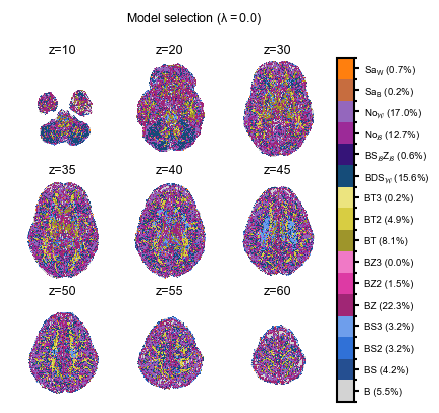

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [7]:
plot_model_segmentation_zgrid(
    "../all_conv_figs/data0_p00/model_probs_preselected_conv_prior_0.0.nii.gz",
    "../all_conv_figs/data0_p00/preselected_models_summary_conv_0.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_sel_all/model_segmentation_conv_00.svg",
    fig_title="Model selection ($\lambda=0.0$)"

)


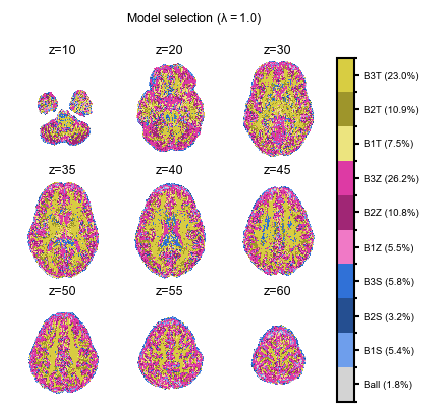

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [23]:
from model_segmentation_plot import plot_model_segmentation, plot_model_freqs, get_model_freq, plot_model_segmentation_zgrid
plot_model_segmentation_zgrid(
    "outputs/data0_p10/model_probs_preselected_prior_1.0.nii.gz",
    "outputs/data0_p10/preselected_models_summary_1.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_all/model_segmentation_10.svg",
    fig_title="Model selection ($\lambda=1.0$)",
)


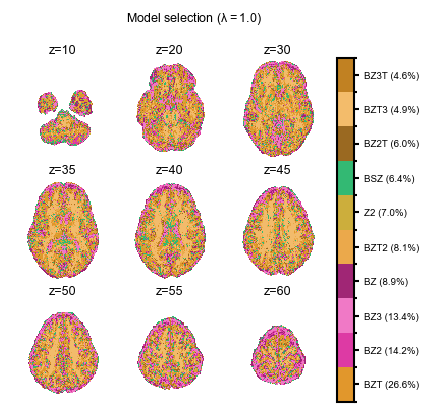

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [16]:
plot_model_segmentation_zgrid(
    "outputs/data0_p10/model_probs_top10_prior_1.0.nii.gz",
    "outputs/data0_p10/top10_models_summary_1.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_all/top10_model_segmentation_10.svg",
    fig_title=r"Model selection ($\lambda=1.0$)",
)

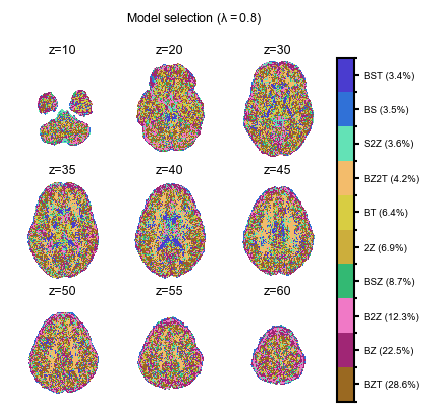

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [35]:
plot_model_segmentation_zgrid(
    "outputs/data0_p08/model_probs_top10_prior_0.8.nii.gz",
    "outputs/data0_p08/top10_models_summary_0.8.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_all/top10_model_segmentation_08.svg",
    fig_title=r"Model selection ($\lambda=0.8$)",
)

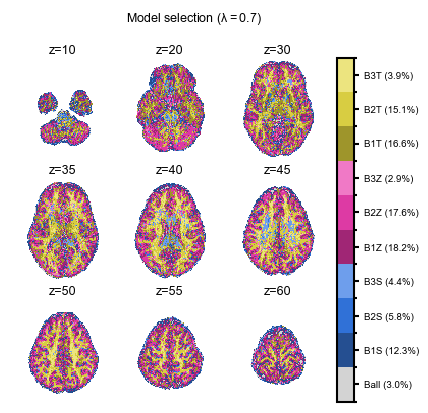

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [19]:
from model_segmentation_plot import plot_model_segmentation, plot_model_freqs, get_model_freq, plot_model_segmentation_zgrid
plot_model_segmentation_zgrid(
    "outputs/data0_p06/model_probs_preselected_prior_0.6.nii.gz",
    "outputs/data0_p06/preselected_models_summary_0.6.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_all/model_segmentation_07.svg",
    fig_title="Model selection ($\lambda=0.7$)",
)


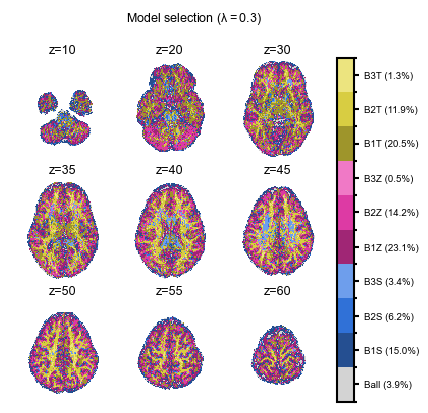

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [20]:
from model_segmentation_plot import plot_model_segmentation, plot_model_freqs, get_model_freq, plot_model_segmentation_zgrid
plot_model_segmentation_zgrid(
    "outputs/data0_p03/model_probs_preselected_prior_0.3.nii.gz",
    "outputs/data0_p03/preselected_models_summary_0.3.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_all/model_segmentation_03.svg",
    fig_title="Model selection ($\lambda=0.3$)",
)


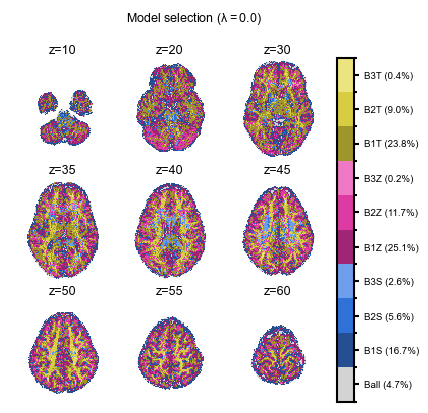

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [21]:
from model_segmentation_plot import plot_model_segmentation, plot_model_freqs, get_model_freq, plot_model_segmentation_zgrid
plot_model_segmentation_zgrid(
    "outputs/data0_p00/model_probs_preselected_prior_0.0.nii.gz",
    "outputs/data0_p00/preselected_models_summary_0.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_all/model_segmentation_00.svg",
    fig_title="Model selection ($\lambda=0.0$)",
)


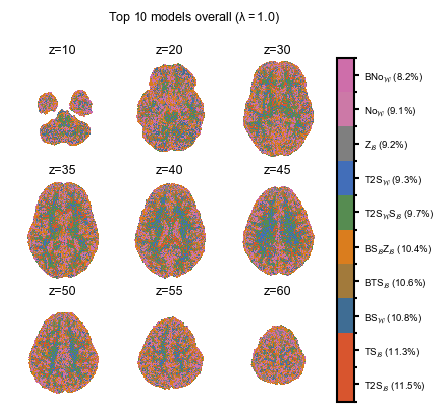

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [18]:
plot_model_segmentation_zgrid(
    "../all_conv_figs/data0_p10/model_probs_top10_conv_prior_1.0.nii.gz",
    "../all_conv_figs/data0_p10/top10_models_summary_conv_1.0.csv",
    group_similar=False,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_sel_all/model_segmentation_conv_10.svg",
    fig_title="Top 10 models overall ($\lambda=1.0$)",
)


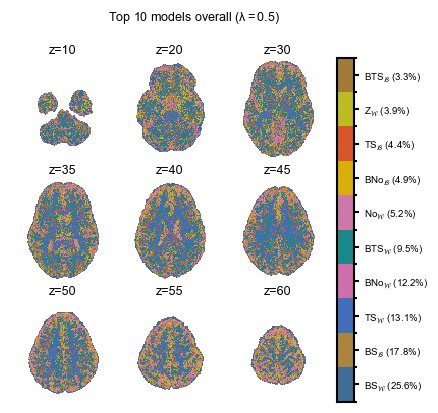

(<Figure size 400x400 with 10 Axes>,
 array([[<Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=20'}>,
         <Axes: title={'center': 'z=30'}>],
        [<Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>,
         <Axes: title={'center': 'z=45'}>],
        [<Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [19]:
plot_model_segmentation_zgrid(
    "../all_conv_figs/data0_p05/model_probs_top10_conv_prior_0.5.nii.gz",
    "../all_conv_figs/data0_p05/top10_models_summary_conv_0.5.csv",
    group_similar=False,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_sel_all/model_segmentation_conv_05.svg",
    fig_title=r"Top 10 models overall ($\lambda=0.5$)",
)


In [ ]:
plot_model_segmentation_zgrid(
    "../all_conv_figs/data0_p10/model_probs_top10_conv_prior_1.0.nii.gz",
    "../all_conv_figs/data0_p10/top10_models_summary_conv_1.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
    output_svg="fig_model_sel_all/model_segmentation_conv_10.svg",
    fig_title="Model selection ($\lambda=1.0$)",
)


In [2]:
plot_model_segmentation_zgrid(
    "../all_conv_figs/data1_p10/model_probs_preselected_conv_prior_1.0.nii.gz",
    "../all_conv_figs/data1_p10/preselected_models_summary_conv_1.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
)

NameError: name 'plot_model_segmentation_zgrid' is not defined

In [ ]:
plot_model_segmentation_zgrid(
    "../all_conv_figs/data0_p10/model_probs_preselected_conv_prior_1.0.nii.gz",
    "../all_conv_figs/data0_p10/preselected_models_summary_conv_1.0.csv",
    group_similar=True,
    ncols=3,
    fig_size=(4,4),
    z_slices=[10,20,30,35,40,45,50,55,60],
)

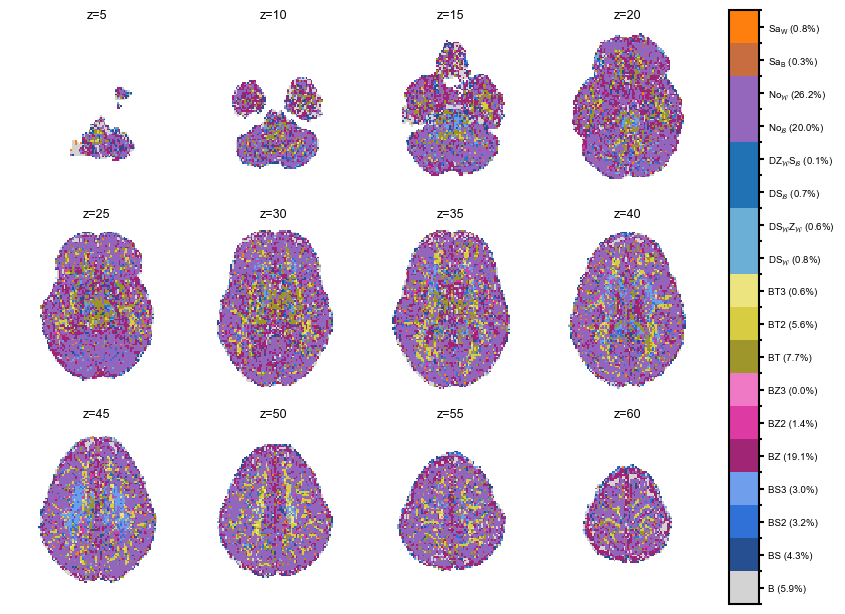

(<Figure size 880x660 with 13 Axes>,
 array([[<Axes: title={'center': 'z=5'}>,
         <Axes: title={'center': 'z=10'}>,
         <Axes: title={'center': 'z=15'}>,
         <Axes: title={'center': 'z=20'}>],
        [<Axes: title={'center': 'z=25'}>,
         <Axes: title={'center': 'z=30'}>,
         <Axes: title={'center': 'z=35'}>,
         <Axes: title={'center': 'z=40'}>],
        [<Axes: title={'center': 'z=45'}>,
         <Axes: title={'center': 'z=50'}>,
         <Axes: title={'center': 'z=55'}>,
         <Axes: title={'center': 'z=60'}>]], dtype=object))

In [5]:
plot_model_segmentation_zgrid(
    "../all_conv_figs/outputs/data0_p01/model_probs_preselected_conv_prior_0.1.nii.gz",
    "../all_conv_figs/outputs/data0_p01/preselected_models_summary_conv_0.1.csv",
    group_similar=True,
    ncols=4,
    z_slices=[5,10,15,20,25,30,35,40,45,50,55,60]
)


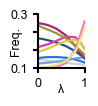

In [24]:
fig, ax = plot_model_freqs(fig_size=(0.6,0.7), group_similar=True, output_png=None, output_svg=None, show=False)
ax.set_ylim(0, 0.3)
ax.set_yticks([0.0,0.1, 0.2,0.3])
ax.set_yticklabels(['0.1', '', '', '0.3'])
ax.set_ylabel("Freq.", labelpad=-8)
fig.savefig("fig_model_all/model_frequencies_in_brain.svg")

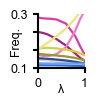

In [25]:
fig, ax = plot_model_freqs(data=1,fig_size=(0.6,0.7), group_similar=True, output_png=None, output_svg=None, show=False)
ax.set_ylim(0, 0.3)
ax.set_ylim(0, 0.3)
ax.set_yticks([0.0,0.1, 0.2,0.3])
ax.set_yticklabels(['0.1', '', '', '0.3'])
ax.set_ylabel("Freq.", labelpad=-8)
fig.savefig("fig_model_all/model_frequencies_in_brain_data1.svg", dpi=300)

In [9]:
get_model_freq(1.0, data=0)

array([0.01771419, 0.05414326, 0.03150456, 0.05826896, 0.05486745,
       0.10768083, 0.26156513, 0.07508778, 0.10912482, 0.23004301])

In [7]:
path1 = 'outputs/data0_p10/model_probs_preselected_prior_1.0.nii.gz'
path2 = 'outputs/data0_p10/model_probs_top10_prior_1.0.nii.gz'
probs_pre = nib.load(path1).get_fdata()
probs_top10 = nib.load(path2).get_fdata()

summary_pre = pd.read_csv('../all_conv_figs/data0_p10/preselected_models_summary_conv_1.0.csv')
summary_top10 = pd.read_csv('../all_conv_figs/data0_p10/top10_models_summary_conv_1.0.csv')

In [8]:
summary_pre

,Model,Count,Mask,DOF
0,Ball,5636,"[True, False, False, False, False, False, Fals...",1
1,Ball>Stick,1962,"[True, True, False, False, False, False, False...",5
2,Ball>Stick>Stick,4709,"[True, True, True, False, False, False, False,...",9
3,Ball>Stick>Stick>Stick,9070,"[True, True, True, True, False, False, False, ...",13
4,Ball>Zeppelin,8693,"[True, False, False, False, True, False, False...",6
5,Ball>Zeppelin>Zeppelin,5568,"[True, False, False, False, True, True, False,...",11
6,Ball>Zeppelin>Zeppelin>Zeppelin,6878,"[True, False, False, False, True, True, True, ...",16
7,Ball>Dti,4170,"[True, False, False, False, False, False, Fals...",8
8,Ball>Dti>Dti,8831,"[True, False, False, False, False, False, Fals...",15
9,Ball>Dti>Dti>Dti,42162,"[True, False, False, False, False, False, Fals...",22


In [11]:
path1 = 'outputs/data1_p10/model_probs_preselected_prior_1.0.nii.gz'
path2 = 'outputs/data1_p10/model_probs_top10_prior_1.0.nii.gz'
probs1_pre = nib.load(path1).get_fdata()
probs1_top10 = nib.load(path2).get_fdata()

summary1_pre = pd.read_csv('outputs/data1_p10/preselected_models_summary_1.0.csv')
summary1_top10 = pd.read_csv('outputs/data1_p10/top10_models_summary_1.0.csv')

In [12]:
summary1_top10

,Model,Count,Mask,DOF
0,Ball>Zeppelin>Zeppelin>Zeppelin,34888,"[True, False, False, False, True, True, True, ...",16
1,Ball>Zeppelin>Zeppelin,28290,"[True, False, False, False, False, True, True,...",11
2,Ball>Zeppelin>Dti,22866,"[True, False, False, False, True, False, False...",13
3,Ball>Zeppelin>Zeppelin>Dti,21819,"[True, False, False, False, True, True, False,...",18
4,Ball>Zeppelin>Zeppelin>Zeppelin>Dti,20120,"[True, False, False, False, True, True, True, ...",23
5,Ball>Stick>Zeppelin>Zeppelin>Zeppelin,19002,"[True, False, True, False, True, True, True, F...",20
6,Ball>Zeppelin,13712,"[True, False, False, False, True, False, False...",6
7,Ball>Stick>Zeppelin>Zeppelin,13259,"[True, False, True, False, True, False, True, ...",15
8,Ball>Stick>Dti,12583,"[True, False, False, True, False, False, False...",12
9,Stick>Zeppelin>Dti,11637,"[False, True, False, False, True, False, False...",15


In [13]:
summary_pre

,Model,Count,Mask,DOF
0,Ball,4036,"[True, False, False, False, False, False, Fals...",1
1,Ball>Stick,12336,"[True, True, False, False, False, False, False...",5
2,Ball>Stick>Stick,7178,"[True, True, True, False, False, False, False,...",9
3,Ball>Stick>Stick>Stick,13276,"[True, True, True, True, False, False, False, ...",13
4,Ball>Zeppelin,12501,"[True, False, False, False, True, False, False...",6
5,Ball>Zeppelin>Zeppelin,24534,"[True, False, False, False, True, True, False,...",11
6,Ball>Zeppelin>Zeppelin>Zeppelin,59595,"[True, False, False, False, True, True, True, ...",16
7,Ball>Dti,17108,"[True, False, False, False, False, False, Fals...",8
8,Ball>Dti>Dti,24863,"[True, False, False, False, False, False, Fals...",15
9,Ball>Dti>Dti>Dti,52413,"[True, False, False, False, False, False, Fals...",22


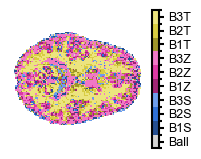

In [6]:
fig = plot_model_segmentation(
    "outputs/data0_p10/model_probs_preselected_prior_1.0.nii.gz",
    "outputs/data0_p10/preselected_models_summary_1.0.csv",
    output_png="all_model_segmentation_data0.png",
    output_svg="all_model_segmentation_data0.svg",
    fig_size=(2.,1.8),
    group_similar=True,
    axial_only=True,
    axial_rotate_k=3,
    show_percent=False,
    show_titles=False,
)
fig.savefig("all_model_segmentation_data0.png", dpi=300)
fig.savefig("all_model_segmentation_data0.svg")

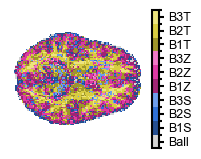

In [9]:
fig = plot_model_segmentation(
    "outputs/data0_p05/model_probs_preselected_prior_0.5.nii.gz",
    "outputs/data0_p05/preselected_models_summary_0.5.csv",
    output_png="all_model_segmentation_data0.png",
    output_svg="all_model_segmentation_data0.svg",
    fig_size=(2.,1.8),
    group_similar=True,
    axial_only=True,
    axial_rotate_k=3,
    show_percent=False,
    show_titles=False,
)
fig.savefig("all_model_segmentation_data0_05.svg")

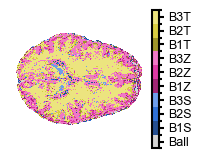

In [8]:
fig = plot_model_segmentation(
    "outputs/data1_p10/model_probs_preselected_prior_1.0.nii.gz",
    "outputs/data1_p10/preselected_models_summary_1.0.csv",
    output_png="all_model_segmentation_data1.png",
    output_svg="all_model_segmentation_data1.svg",
    fig_size=(2.,1.8),
    group_similar=True,
    axial_only=True,
    axial_rotate_k=3,
    show_percent=False,
    show_titles=False,
)
fig.savefig("all_model_segmentation_data1.png", dpi=300)

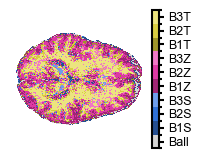

In [12]:
fig = plot_model_segmentation(
    "outputs/data1_p04/model_probs_preselected_prior_0.4.nii.gz",
    "outputs/data1_p04/preselected_models_summary_0.4.csv",
    output_png="all_model_segmentation_data1.png",
    output_svg="all_model_segmentation_data1.svg",
    fig_size=(2.,1.8),
    group_similar=True,
    axial_only=True,
    axial_rotate_k=3,
    show_percent=False,
    show_titles=False,
)
fig.savefig("all_model_segmentation_data1_05.svg", dpi=300)

In [6]:
plot_model_segmentation(
    "data0_p05/model_probs_preselected_prior_0.5.nii.gz",
    "data0_p05/preselected_models_summary_0.5.csv",
    output_png="all_model_segmentation_data0.png",
    output_svg="all_model_segmentation_data0.svg",
    group_similar=True,
)


FileNotFoundError: No such file or no access: 'data0_p05/model_probs_preselected_prior_0.5.nii.gz'

In [10]:
plot_model_segmentation(
    "data0_p01/model_probs_preselected_prior_0.1.nii.gz",
    "data0_p01/preselected_models_summary_0.1.csv",
    output_png="all_model_segmentation_data0.png",
    output_svg="all_model_segmentation_data0.svg",
)


FileNotFoundError: No such file or no access: 'data0_p01/model_probs_preselected_prior_0.1.nii.gz'

In [5]:
plot_model_segmentation(
    "data1_p10/model_probs_preselected_prior_1.0.nii.gz",
    "data1_p10/preselected_models_summary_1.0.csv",
    output_png="all_model_segmentation_data1.png",
    output_svg="all_model_segmentation_data1.svg",
)


FileNotFoundError: No such file or no access: 'data1_p10/model_probs_preselected_prior_1.0.nii.gz'

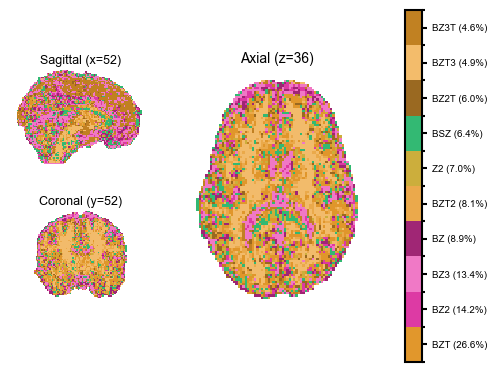

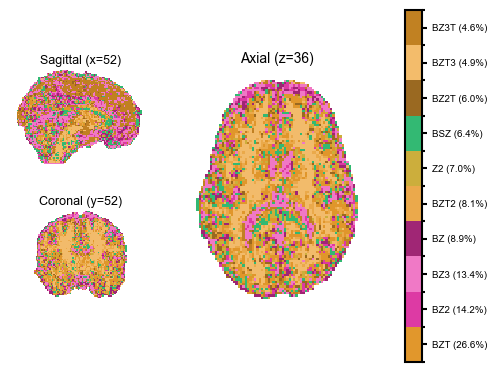

In [11]:
plot_model_segmentation(
    "outputs/data0_p10/model_probs_top10_prior_1.0.nii.gz",
    "outputs/data0_p10/top10_models_summary_1.0.csv",
    output_png="all_model_segmentation_top10_data0.png",
    output_svg="all_model_segmentation_top10_data0.svg",
)


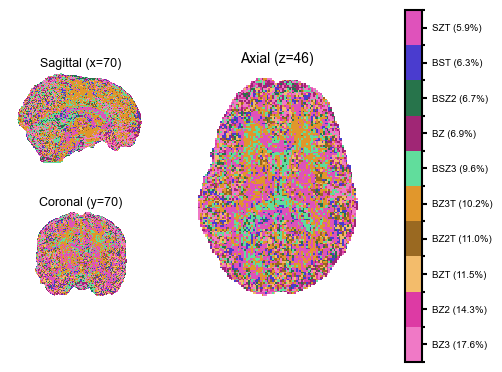

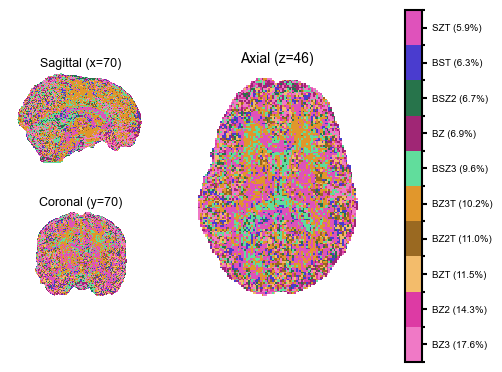

In [17]:
plot_model_segmentation(
    "outputs/data1_p10/model_probs_top10_prior_1.0.nii.gz",
    "outputs/data1_p10/top10_models_summary_1.0.csv",
    output_png="all_model_segmentation_top10_data1.png",
    output_svg="all_model_segmentation_top10_data1.svg",
)


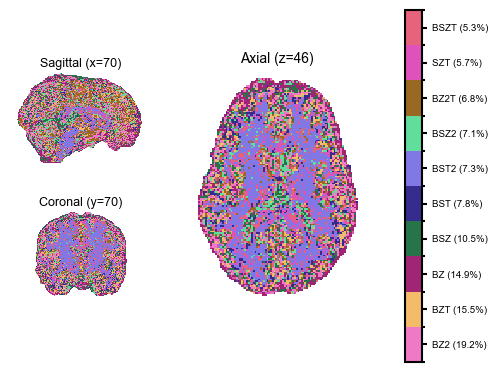

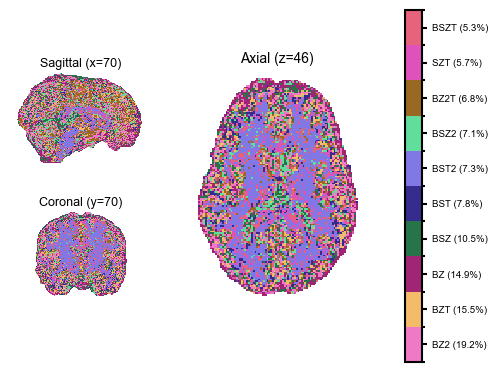

In [18]:
plot_model_segmentation(
    "outputs/data1_p08/model_probs_top10_prior_0.8.nii.gz",
    "outputs/data1_p08/top10_models_summary_0.8.csv",
    output_png="all_model_segmentation_top10_data1_08.png",
    output_svg="all_model_segmentation_top10_data1_08.svg",
)


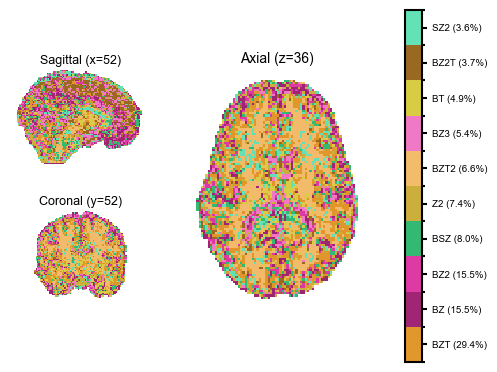

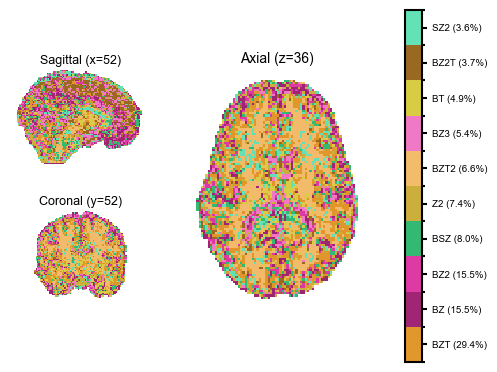

In [15]:
plot_model_segmentation(
    "outputs/data0_p09/model_probs_top10_prior_0.9.nii.gz",
    "outputs/data0_p09/top10_models_summary_0.9.csv",
    output_png="all_model_segmentation_top10_data0_09.png",
    output_svg="all_model_segmentation_top10_data0_09.svg",
)


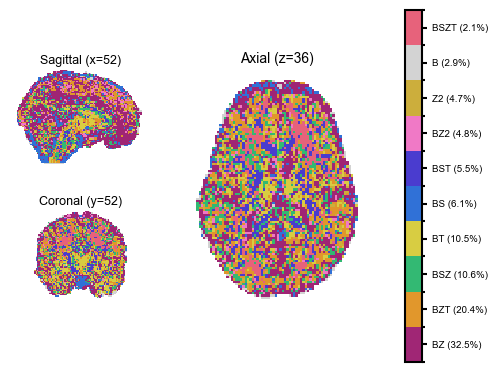

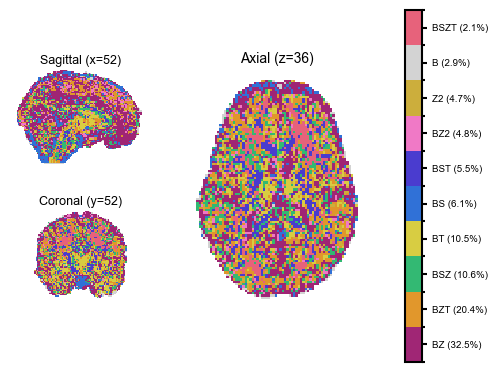

In [11]:
plot_model_segmentation(
    "outputs/data0_p05/model_probs_top10_prior_0.5.nii.gz",
    "outputs/data0_p05/top10_models_summary_0.5.csv",
    output_png="all_model_segmentation_top10_data0_05.png",
    output_svg="all_model_segmentation_top10_data0_05.svg",
)


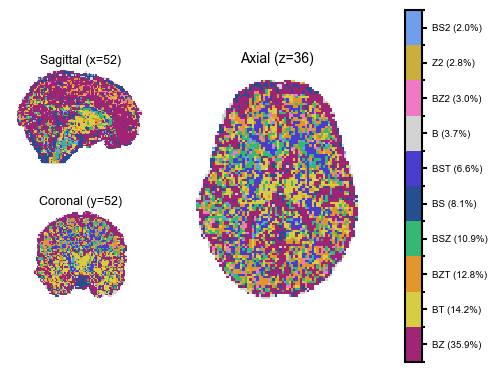

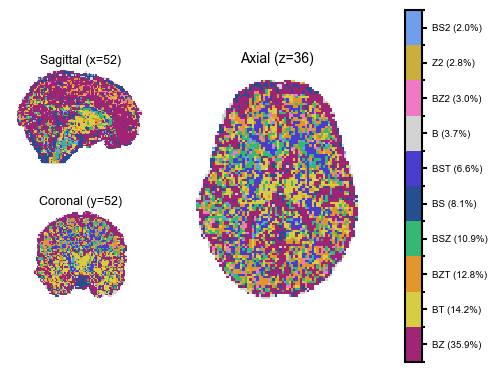

In [12]:
plot_model_segmentation(
    "outputs/data0_p01/model_probs_top10_prior_0.1.nii.gz",
    "outputs/data0_p01/top10_models_summary_0.1.csv",
    output_png="all_model_segmentation_top10_data0_01.png",
    output_svg="all_model_segmentation_top10_data0_01.svg",
)


In [4]:
plot_model_segmentation(
    "data1_p10/model_probs_top10_prior_1.0.nii.gz",
    "data1_p10/top10_models_summary_1.0.csv",
    output_png="all_model_segmentation_top10_data1.png",
    output_svg="all_model_segmentation_top10_data1.svg",
)


FileNotFoundError: No such file or no access: 'data1_p10/model_probs_top10_prior_1.0.nii.gz'

In [ ]:
plot_model_segmentation(
    "data0_p01/model_probs_preselected_prior_0.1.nii.gz",
    "data0_p01/preselected_models_summary_0.1.csv",
    output_png="all_model_segmentation_data0.png",
    output_svg="all_model_segmentation_data0.svg",
)
